In [39]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [40]:
files = list(Path("../data").rglob("*.xls*"))
print(f'Number of files: {len(files)}')

for file in files:
    print(file)

Number of files: 18
../data/2025/23MARCH25-1MAY25.xls
../data/2025/AUG 2025.xls
../data/2025/DEC 2025.xls
../data/2025/JAN 2025.xls
../data/2025/JULY 2025.xls
../data/2025/JuNE 2025.xls
../data/2025/MAY 2025.xls
../data/2025/NOV2025.xls
../data/2025/OCT 2025.xls
../data/2025/SEP 2025.xls
../data/2026/APR20-MAY42026.xls
../data/2026/August 2026.xls
../data/2026/FEB 2026.xls
../data/2026/JAN 2026.xls
../data/2026/JULY2026.xls
../data/2026/june 2026.xls
../data/2026/MARCH-APR 20.xls
../data/2026/MAY 2026.xls


In [41]:
df = pd.read_csv(files[0], sep='\t')
df.columns

Index(['Date(dd/mm/yy)', 'Time(HH:MM)', 'W Direction(Deg)', 'Temp(Deg C)',
       'R Humidity(%)', 'Solar(CCM)', 'B Pressure(mmHg)', 'Spd(Km/hr)',
       'Rain(mm)', 'Unnamed: 9'],
      dtype='str')

In [42]:
rainfall_data = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df = df[
        [
            'Date(dd/mm/yy)',
            'Time(HH:MM)',
            'Rain(mm)'            
        ]
    ]
    rainfall_data.append(df)

rainfall_data = pd.concat(rainfall_data, ignore_index=True)
rainfall_data.head(20)

,Date(dd/mm/yy),Time(HH:MM),Rain(mm)
0,24/03/25,13:57,NaN
1,24/03/25,14:00,0.0
2,24/03/25,14:27,NaN
3,24/03/25,14:46,NaN
4,24/03/25,15:23,NaN
5,24/03/25,15:23,NaN
6,24/03/25,15:25,NaN
7,24/03/25,15:27,NaN
8,24/03/25,15:28,NaN
9,24/03/25,16:00,0.0


In [43]:
print(f'Total Rows: {len(rainfall_data)}')
print("------------------------------------------")
print(f'Missing values:\n{rainfall_data.isna().sum()}')
print("------------------------------------------")
print(f'Rainfall data types:\n{rainfall_data["Rain(mm)"].dtype}')
print("------------------------------------------")
print(f'rainfall Statistics:')
print(
    pd.to_numeric(
        rainfall_data["Rain(mm)"],
        errors="coerce"
    ).describe()
)
print("------------------------------------------")
print("\nNon-numeric rainfall values:")

rain_numeric = pd.to_numeric(
    rainfall_data["Rain(mm)"],
    errors="coerce"
)

print(
    rainfall_data.loc[
        rain_numeric.isna(),
        "Rain(mm)"
    ].value_counts()
)

Total Rows: 12692
------------------------------------------
Missing values:
Date(dd/mm/yy)      0
Time(HH:MM)         0
Rain(mm)          255
dtype: int64
------------------------------------------
Rainfall data types:
object
------------------------------------------
rainfall Statistics:
count    12360.00000
mean        13.54733
std         92.63568
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max        993.50000
Name: Rain(mm), dtype: float64
------------------------------------------

Non-numeric rainfall values:
Rain(mm)
-Transfer Error-    77
Name: count, dtype: int64


In [44]:
rainfall_data["Rain(mm)"] = pd.to_numeric(
    rainfall_data["Rain(mm)"],
    errors="coerce"
)

rainfall_clean = rainfall_data.dropna(
    subset=["Rain(mm)"]
).copy()
print("Rows before:", len(rainfall_data))
print("Rows after:", len(rainfall_clean))

print("\nRainfall range:")
print(
    rainfall_clean["Rain(mm)"].min(),
    rainfall_clean["Rain(mm)"].max()
)

Rows before: 12692
Rows after: 12360

Rainfall range:
0.0 993.5


In [45]:
print(
    rainfall_clean[
        rainfall_clean["Rain(mm)"] > 0
    ][
        ["Date(dd/mm/yy)", "Time(HH:MM)", "Rain(mm)"]
    ].head(30)
)
print(
    rainfall_clean.nlargest(
        20,
        "Rain(mm)"
    )[
        ["Date(dd/mm/yy)", "Time(HH:MM)", "Rain(mm)"]
    ]
)

     Date(dd/mm/yy) Time(HH:MM)  Rain(mm)
229        02/04/25        3:00       1.0
230        02/04/25        4:00       0.5
260        03/04/25        8:00       0.5
265        03/04/25       12:00       0.5
266        03/04/25       13:00       1.0
267        03/04/25       14:00      10.0
426        09/04/25       17:00       5.5
427        09/04/25       18:00       1.0
1363       16/08/25       16:00       0.5
3144       27/12/24       15:00       1.0
3145       27/12/24       16:00       0.5
3146       27/12/24       17:00       0.5
3347       03/07/25       16:00       0.5
3351       03/07/25       20:00       9.0
3352       03/07/25       21:00       4.5
3353       03/07/25       22:00       2.0
3354       03/07/25       23:00       1.0
3355       04/07/25        0:00       1.0
3357       04/07/25        2:00       0.5
3361       04/07/25        6:00       0.5
3406       06/07/25        3:00       0.5
3407       06/07/25        4:00       0.5
3426       06/07/25       23:00   

In [46]:
rainfall_clean["Datetime"] = pd.to_datetime(
    rainfall_clean["Date(dd/mm/yy)"] + " " +
    rainfall_clean["Time(HH:MM)"],
    dayfirst=True,
    errors="coerce"
)

rainfall_clean = rainfall_clean.sort_values("Datetime").copy()
print(
    rainfall_clean[
        (rainfall_clean["Datetime"] >= "2026-04-27") &
        (rainfall_clean["Datetime"] <= "2026-05-02")
    ][
        ["Datetime", "Rain(mm)"]
    ].to_string(index=False)
)
print(
    rainfall_clean[
        rainfall_clean["Rain(mm)"] > 100
    ][
        ["Datetime", "Rain(mm)"]
    ].head(50).to_string(index=False)
)
print(
    rainfall_clean[
        rainfall_clean["Rain(mm)"] > 100
    ][
        ["Datetime", "Rain(mm)"]
    ].tail(50).to_string(index=False)
)

/tmp/ipykernel_6623/177987675.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rainfall_clean["Datetime"] = pd.to_datetime(


           Datetime  Rain(mm)
2026-04-27 00:00:00     367.5
2026-04-27 01:00:00     734.5
2026-04-27 02:00:00       3.5
2026-04-27 03:00:00     918.0
2026-04-27 04:00:00     327.5
2026-04-27 05:00:00     748.0
2026-04-27 06:00:00     681.0
2026-04-27 07:00:00     387.5
2026-04-27 08:00:00      19.5
2026-04-27 09:00:00     571.0
2026-04-27 10:00:00     376.5
2026-04-27 11:00:00     573.0
2026-04-27 12:00:00      92.5
2026-04-27 13:00:00     721.0
2026-04-27 14:00:00     654.5
2026-04-27 15:00:00     949.5
2026-04-27 16:00:00     444.5
2026-04-27 17:00:00     698.0
2026-04-27 18:00:00     153.5
2026-04-27 19:00:00     848.0
2026-04-27 20:00:00     589.0
2026-04-27 21:00:00     543.5
2026-04-27 22:00:00     702.0
2026-04-27 23:00:00     991.0
2026-04-28 00:00:00     922.0
2026-04-28 01:00:00     117.5
2026-04-28 02:00:00     478.5
2026-04-28 03:00:00     455.5
2026-04-28 04:00:00     784.5
2026-04-28 05:00:00     879.0
2026-04-28 06:00:00      24.0
2026-04-28 07:00:00     803.5
2026-04-28

In [47]:
print(
    rainfall_clean[
        rainfall_clean["Rain(mm)"] > 100
    ][
        ["Datetime", "Rain(mm)"]
    ].to_string(index=False)
)
print(
    rainfall_clean[
        rainfall_clean["Rain(mm)"] > 100
    ].shape[0]
)

           Datetime  Rain(mm)
2026-04-20 14:00:00     729.5
2026-04-20 15:00:00     119.5
2026-04-20 16:00:00     246.0
2026-04-20 17:00:00     633.5
2026-04-20 18:00:00     944.5
2026-04-20 19:00:00     825.0
2026-04-20 20:00:00     432.5
2026-04-20 22:00:00     993.5
2026-04-20 23:00:00     774.5
2026-04-21 00:00:00     734.0
2026-04-21 01:00:00     447.5
2026-04-21 02:00:00     179.5
2026-04-21 03:00:00     110.0
2026-04-21 04:00:00     359.0
2026-04-21 05:00:00     511.5
2026-04-21 06:00:00     424.5
2026-04-21 07:00:00     949.5
2026-04-21 08:00:00     351.5
2026-04-21 09:00:00     586.0
2026-04-21 10:00:00     440.0
2026-04-21 11:00:00     160.0
2026-04-21 12:00:00     456.0
2026-04-21 13:00:00     461.0
2026-04-21 14:00:00     781.5
2026-04-21 15:00:00     183.5
2026-04-21 16:00:00     515.0
2026-04-21 17:00:00     758.0
2026-04-21 18:00:00     191.0
2026-04-21 19:00:00     549.5
2026-04-21 20:00:00     620.0
2026-04-21 21:00:00     191.0
2026-04-21 22:00:00     369.0
2026-04-21

In [48]:
print(
    rainfall_clean[
        (rainfall_clean["Datetime"] >= "2026-04-15") &
        (rainfall_clean["Datetime"] <= "2026-04-22")
    ][
        ["Datetime", "Rain(mm)"]
    ].to_string(index=False)
)
print(
    rainfall_clean[
        (rainfall_clean["Datetime"] >= "2026-05-03") &
        (rainfall_clean["Datetime"] <= "2026-05-06")
    ][
        ["Datetime", "Rain(mm)"]
    ].to_string(index=False)
)
rainfall_clean["Datetime"] = pd.to_datetime(
    rainfall_clean["Date(dd/mm/yy)"].astype(str) + " " +
    rainfall_clean["Time(HH:MM)"].astype(str),
    dayfirst=True,
    errors="coerce"
)
rainfall_clean = rainfall_clean.sort_values("Datetime").copy()

           Datetime  Rain(mm)
2026-04-20 13:00:00       0.0
2026-04-20 14:00:00     729.5
2026-04-20 15:00:00     119.5
2026-04-20 16:00:00     246.0
2026-04-20 17:00:00     633.5
2026-04-20 18:00:00     944.5
2026-04-20 19:00:00     825.0
2026-04-20 20:00:00     432.5
2026-04-20 21:00:00      41.5
2026-04-20 22:00:00     993.5
2026-04-20 23:00:00     774.5
2026-04-21 00:00:00     734.0
2026-04-21 01:00:00     447.5
2026-04-21 02:00:00     179.5
2026-04-21 03:00:00     110.0
2026-04-21 04:00:00     359.0
2026-04-21 05:00:00     511.5
2026-04-21 06:00:00     424.5
2026-04-21 07:00:00     949.5
2026-04-21 08:00:00     351.5
2026-04-21 09:00:00     586.0
2026-04-21 10:00:00     440.0
2026-04-21 11:00:00     160.0
2026-04-21 12:00:00     456.0
2026-04-21 13:00:00     461.0
2026-04-21 14:00:00     781.5
2026-04-21 15:00:00     183.5
2026-04-21 16:00:00     515.0
2026-04-21 17:00:00     758.0
2026-04-21 18:00:00     191.0
2026-04-21 19:00:00     549.5
2026-04-21 20:00:00     620.0
2026-04-21

/tmp/ipykernel_6623/3681017465.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rainfall_clean["Datetime"] = pd.to_datetime(


In [49]:
print(
    rainfall_clean[
        (rainfall_clean["Datetime"] >= "2026-04-19") &
        (rainfall_clean["Datetime"] <= "2026-05-06")
    ][["Datetime", "Rain(mm)"]].to_string(index=False)
)
rainfall_clean["Datetime"] = pd.to_datetime(
    rainfall_clean["Date(dd/mm/yy)"].astype(str)
    + " "
    + rainfall_clean["Time(HH:MM)"].astype(str),
    dayfirst=True,
    format="mixed",
    errors="coerce"
)
rainfall_clean = rainfall_clean.sort_values("Datetime").copy()

           Datetime  Rain(mm)
2026-04-20 13:00:00       0.0
2026-04-20 14:00:00     729.5
2026-04-20 15:00:00     119.5
2026-04-20 16:00:00     246.0
2026-04-20 17:00:00     633.5
2026-04-20 18:00:00     944.5
2026-04-20 19:00:00     825.0
2026-04-20 20:00:00     432.5
2026-04-20 21:00:00      41.5
2026-04-20 22:00:00     993.5
2026-04-20 23:00:00     774.5
2026-04-21 00:00:00     734.0
2026-04-21 01:00:00     447.5
2026-04-21 02:00:00     179.5
2026-04-21 03:00:00     110.0
2026-04-21 04:00:00     359.0
2026-04-21 05:00:00     511.5
2026-04-21 06:00:00     424.5
2026-04-21 07:00:00     949.5
2026-04-21 08:00:00     351.5
2026-04-21 09:00:00     586.0
2026-04-21 10:00:00     440.0
2026-04-21 11:00:00     160.0
2026-04-21 12:00:00     456.0
2026-04-21 13:00:00     461.0
2026-04-21 14:00:00     781.5
2026-04-21 15:00:00     183.5
2026-04-21 16:00:00     515.0
2026-04-21 17:00:00     758.0
2026-04-21 18:00:00     191.0
2026-04-21 19:00:00     549.5
2026-04-21 20:00:00     620.0
2026-04-21

In [50]:
last_abnormal = rainfall_clean[
    rainfall_clean["Rain(mm)"] > 100
].sort_values("Datetime").tail(1)

print(last_abnormal)
first_abnormal = rainfall_clean[
    rainfall_clean["Rain(mm)"] > 100
].sort_values("Datetime").head(1)

print(first_abnormal)

     Date(dd/mm/yy) Time(HH:MM)  Rain(mm)            Datetime
8055       04/05/26       14:00     135.5 2026-05-04 14:00:00
     Date(dd/mm/yy) Time(HH:MM)  Rain(mm)            Datetime
7719       20/04/26       14:00     729.5 2026-04-20 14:00:00


In [51]:
abnormal_start = pd.Timestamp("2026-04-20 14:00")
abnormal_end = pd.Timestamp("2026-05-04 14:00")

rainfall_refined = rainfall_clean[
    ~(
        (rainfall_clean["Datetime"] >= abnormal_start) &
        (rainfall_clean["Datetime"] <= abnormal_end)
    )
].copy()
print("Before refinement:", len(rainfall_clean))
print("After refinement:", len(rainfall_refined))

print("\nRainfall statistics:")
print(rainfall_refined["Rain(mm)"].describe())
print(
    rainfall_refined.nlargest(
        20, "Rain(mm)"
    )[["Datetime", "Rain(mm)"]]
)

Before refinement: 12360
After refinement: 12023

Rainfall statistics:
count    12023.000000
mean         0.027531
std          0.525422
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         28.000000
Name: Rain(mm), dtype: float64
                Datetime  Rain(mm)
4605 2025-06-25 23:00:00      28.0
4721 2025-06-30 19:00:00      27.0
4600 2025-06-25 18:00:00      23.5
5412 2025-05-28 18:00:00      19.0
5246 2025-05-21 20:00:00      11.0
267  2025-04-03 14:00:00      10.0
4573 2025-06-24 15:00:00       9.5
4720 2025-06-30 18:00:00       9.5
3351 2025-07-03 20:00:00       9.0
4606 2025-06-26 00:00:00       8.5
4604 2025-06-25 22:00:00       7.0
5247 2025-05-21 21:00:00       6.0
426  2025-04-09 17:00:00       5.5
6746 2025-10-30 03:00:00       5.0
3352 2025-07-03 21:00:00       4.5
6753 2025-10-30 10:00:00       4.5
6836 2025-11-02 21:00:00       3.5
4982 2025-05-10 20:00:00       3.0
4599 2025-06-25 17:00:00       3.0
4722 2025-06-30 20:00:

In [52]:
rainfall_refined["Month"] = rainfall_refined["Datetime"].dt.to_period("M")

monthly_rainfall = (
    rainfall_refined
    .groupby("Month")["Rain(mm)"]
    .sum()
    .reset_index()
)

print(monthly_rainfall)

      Month  Rain(mm)
0   2024-12       2.0
1   2025-01       0.0
2   2025-03       0.0
3   2025-04      20.0
4   2025-05      54.5
5   2025-06     148.5
6   2025-07      33.0
7   2025-08       0.5
8   2025-09       6.5
9   2025-10      21.0
10  2025-11       6.0
11  2025-12       0.0
12  2026-01       0.0
13  2026-02       0.0
14  2026-03       0.0
15  2026-04       0.0
16  2026-05       0.5
17  2026-06       3.0
18  2026-07      24.0
19  2026-08       6.5
20  2026-09       5.0


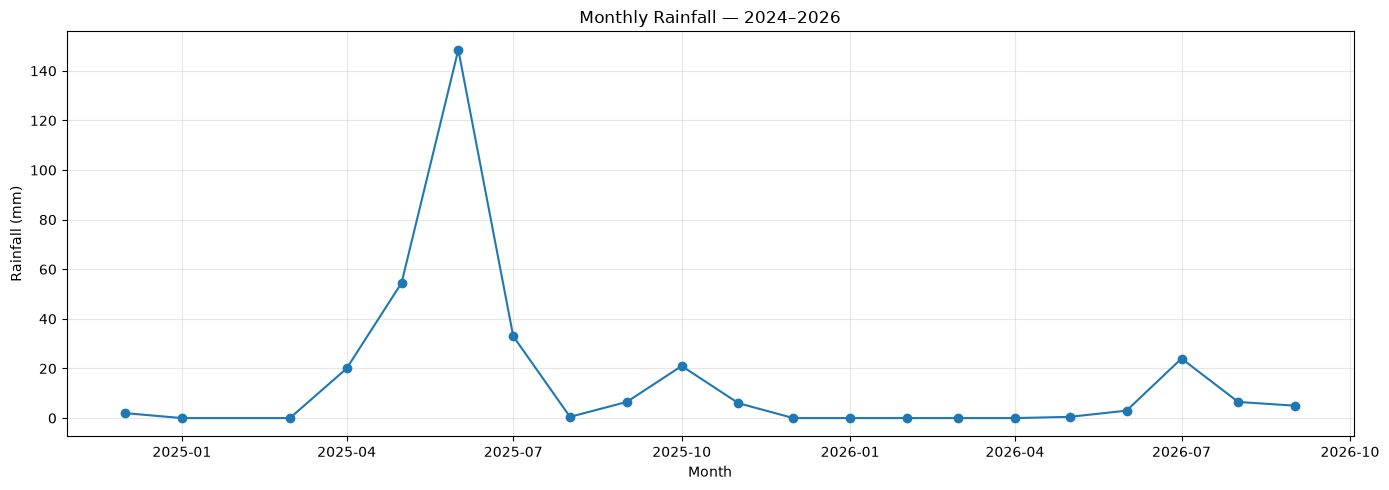

In [53]:
monthly_rainfall["Month_start"] = monthly_rainfall["Month"].dt.to_timestamp()

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_rainfall["Month_start"],
    monthly_rainfall["Rain(mm)"],
    marker="o",
    linewidth=1.5
)

plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly Rainfall — 2024–2026")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
rainfall_refined["Week"] = (
    rainfall_refined["Datetime"]
    .dt.to_period("W-SUN")
)

weekly_rainfall = (
    rainfall_refined
    .groupby("Week")["Rain(mm)"]
    .sum()
    .reset_index()
)

print(weekly_rainfall)

                     Week  Rain(mm)
0   2024-12-02/2024-12-08       0.0
1   2024-12-09/2024-12-15       0.0
2   2024-12-16/2024-12-22       0.0
3   2024-12-23/2024-12-29       2.0
4   2024-12-30/2025-01-05       0.0
..                    ...       ...
70  2026-08-10/2026-08-16       1.0
71  2026-08-17/2026-08-23       1.5
72  2026-08-24/2026-08-30       1.5
73  2026-08-31/2026-09-06       5.0
74  2026-09-07/2026-09-13       0.0

[75 rows x 2 columns]


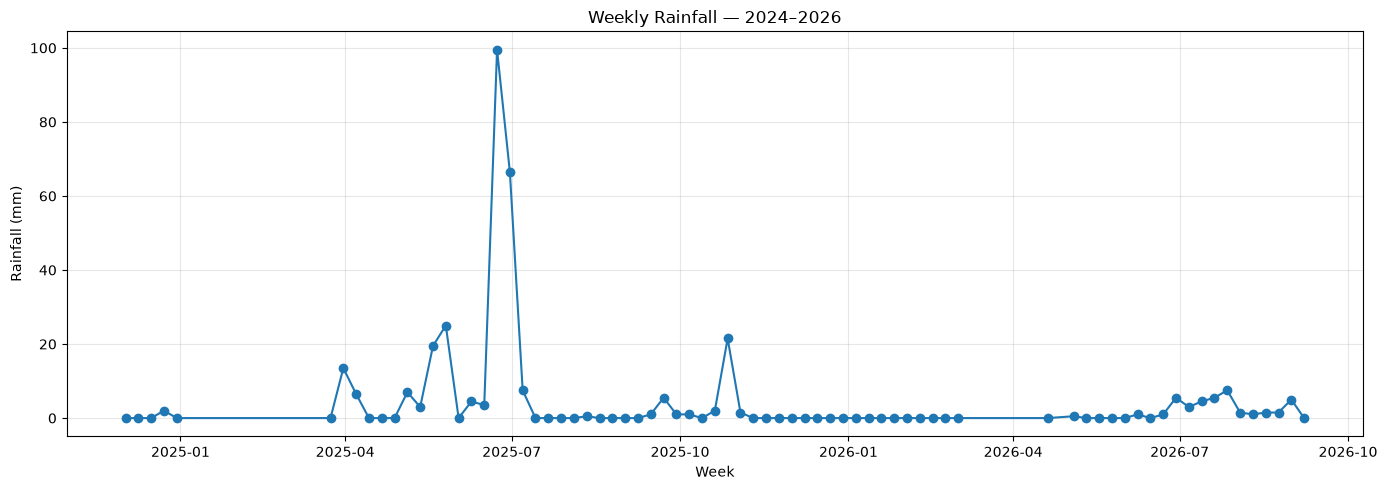

In [55]:
import matplotlib.pyplot as plt

weekly_rainfall["Week_start"] = weekly_rainfall["Week"].dt.start_time

plt.figure(figsize=(14, 5))

plt.plot(
    weekly_rainfall["Week_start"],
    weekly_rainfall["Rain(mm)"],
    marker="o",
    linewidth=1.5
)

plt.xlabel("Week")
plt.ylabel("Rainfall (mm)")
plt.title("Weekly Rainfall — 2024–2026")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()